In [1]:
# 1. IMPORTING LIBRARIES
import os
import zipfile
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from google.colab import files

print("Please upload your kaggle.json file:")
files.upload()

# 2. DOWNLOADING THE DATASET
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Fetching LeapGestRecog Dataset...")
!kaggle datasets download -d gti-upm/leapgestrecog

# 3. EXTRACTING AND RESTRUCTURING DATA
print("Extracting and preparing data architecture...")
with zipfile.ZipFile("leapgestrecog.zip", 'r') as zip_ref:
    zip_ref.extractall("/tmp/leap_raw/")

base_dir = '/tmp/leap_raw/leapGestRecog'
dataset_dir = '/tmp/leap_dataset'
os.makedirs(dataset_dir, exist_ok=True)

# Flattening the folder structure for Keras
for subject in os.listdir(base_dir):
    subject_path = os.path.join(base_dir, subject)
    if os.path.isdir(subject_path):
        for gesture in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture)
            if os.path.isdir(gesture_path):
                class_dir = os.path.join(dataset_dir, gesture)
                os.makedirs(class_dir, exist_ok=True)
                for img in os.listdir(gesture_path):
                    shutil.move(os.path.join(gesture_path, img), os.path.join(class_dir, f"{subject}_{img}"))

print("✅ Data Pipeline Ready!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Fetching LeapGestRecog Dataset...
Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [09:08<00:00, 4.17MB/s]

Extracting and preparing data architecture...
✅ Data Pipeline Ready!


Found 20000 files belonging to 10 classes.
Using 16000 files for training.
Found 20000 files belonging to 10 classes.
Using 4000 files for validation.


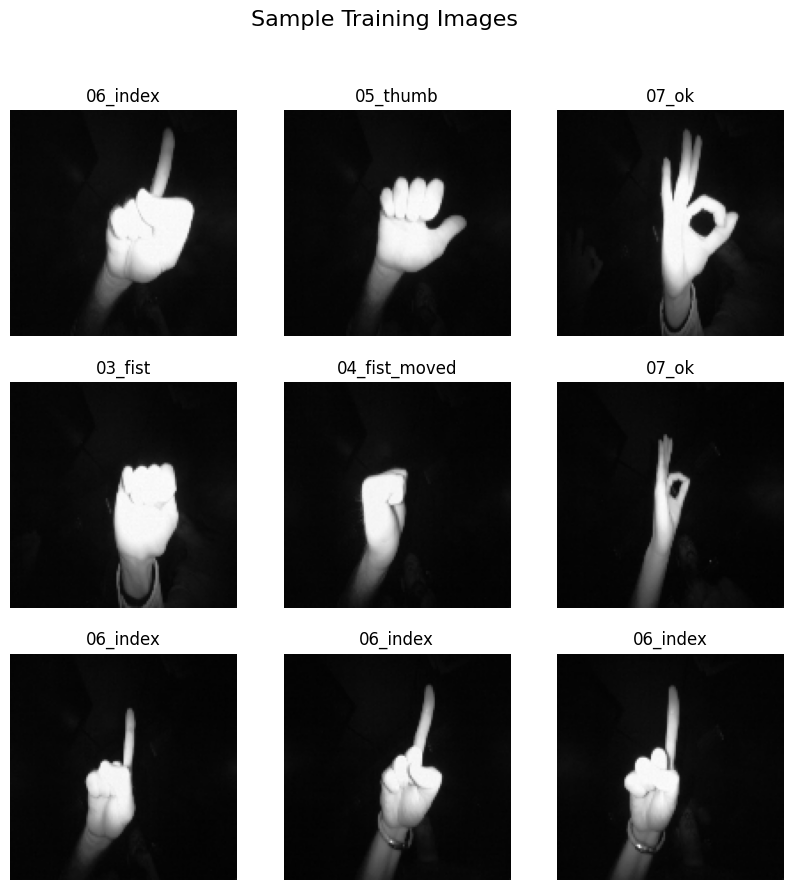

In [2]:
# 1. CREATING DATA GENERATORS
BATCH_SIZE = 64
IMAGE_SIZE = (128, 128)

# Splitting data into 80% Training and 20% Validation
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_dataset.class_names

# 2. VISUALIZING THE DATASET (EDA)
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        # Getting the string label from the one-hot encoded array
        label_index = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_index])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.show()

In [3]:
# BUILDING A CUSTOM CONVOLUTIONAL NEURAL NETWORK (CNN)
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255, name="Normalization_Layer"), # Scaling pixels

    # Block 1: Feature Extraction
    layers.Conv2D(32, (3, 3), activation='relu', name="Conv_1"),
    layers.MaxPooling2D(2, 2, name="MaxPool_1"),

    # Block 2: Deeper Features
    layers.Conv2D(64, (3, 3), activation='relu', name="Conv_2"),
    layers.MaxPooling2D(2, 2, name="MaxPool_2"),

    # Block 3: Complex Patterns
    layers.Conv2D(128, (3, 3), activation='relu', name="Conv_3"),
    layers.MaxPooling2D(2, 2, name="MaxPool_3"),

    # Classification Head
    layers.Flatten(name="Flatten_Layer"),
    layers.Dense(256, activation='relu', name="Dense_Hidden"),
    layers.Dropout(0.5, name="Dropout_Regularization"), # Preventing Overfitting

    # Output Layer: 10 Classes
    layers.Dense(10, activation='softmax', name="Output_Layer")
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary() # Yeh table submission mein bohot professional lagti hai

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Normalization_Layer (Rescaling) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_3 (MaxPooling2D)        │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten_Layer (Flatten)         │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Regularization          │ (None, 256)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,602 (24.87 MB)

 Trainable params: 6,518,602 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STARTING THE TRAINING PROCESS
EPOCHS = 6

print("Initiating Model Training Phase...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# SAVING THE MODEL
model.save('vision_gesture_submission_model.keras')
print("✅ Model successfully trained and saved!")

# PLOTTING TRAINING RESULTS (The Flex for Evaluators)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Graph 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, marker='o')
plt.legend(loc='lower right')
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

# Graph 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, marker='o', color='orange')
plt.legend(loc='upper right')
plt.title('Model Loss Reduction')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Initiating Model Training Phase...
Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 641s 3s/step - accuracy: 0.9030 - loss: 0.2919 - val_accuracy: 0.9985 - val_loss: 0.0025
Epoch 2/6
 25/250 ━━━━━━━━━━━━━━━━━━━━ 8:12 2s/step - accuracy: 0.9920 - loss: 0.0338